# ANME

## 1) TIME PLAN & GOALS (10/70/10)

**Duration:** 90 minutes
- **10 min:** Introduction & Theoretical Bridge (Instructor)
- **70 min:** Guided Lab Work (Modules A-G)
- **10 min:** Summary, Checklist, and Check-questions

**Goals of the Lab:**
1. Understand Gradient Descent (GD) and Stochastic Gradient Descent (SGD) not just as black-box optimizers, but as discrete numerical dynamical systems.
2. Observe the impact of learning rate, batch size, and landscape geometry (convex vs. non-convex, ill-conditioning).
3. Implement and understand advanced concepts: Armijo line-search, Momentum/Nesterov, and ODE/SDE views (Heun's method, Langevin Dynamics).
4. Diagnose and solve common numerical issues in Deep Learning (exploding/vanishing gradients, numerical overflows).

**"After this lab, you will be able to..."**
- Implement standard GD, SGD, and Momentum from scratch.
- Automatically tune learning rates using Armijo line search.
- Explain why optimization is related to physics (Gradient Flow, Heavy Ball, Thermodynamics/SDE).
- Stabilize numerically unstable calculations (e.g., using the Log-Sum-Exp trick and gradient clipping).

---

## 2) INTRO

*   **GD as an iteration:**  $x_{k+1} = x_k - \eta \nabla f(x_k)$.
*   **When does it work?** Convexity guarantees a global minimum. Lipschitz continuity of the gradient bounds how fast the derivative changes, defining the maximum safe step size ($\eta$).
*   **Convex vs Non-Convex:** Convex = a bowl. Non-convex = mountains and valleys. GD is greedy; it goes to the nearest local valley.
*   **The Bridge to ODE/SDE:**
    *   If $\eta \to 0$, $x_{k+1} - x_k \approx dx$, leading to Gradient Flow (ODE): $\dot{x} = -\nabla f(x)$.
    *   Adding noise (SGD minibatches) makes it a Stochastic Differential Equation (SDE): Brownian motion exploring the landscape.
*   **Preview:** Today we will see how choosing $\eta$ dictates stability, how Momentum speeds us up, how noise saves us from local minima, and why computers struggle with raw math (numerical limits).

## 3) Exercise

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)

ModuleNotFoundError: No module named 'seaborn'

### Module A: GD from scratch & 1D Convergence

**Goal:** Implement GD and visualize how the learning rate ($\eta$) affects convex and non-convex functions.

**Math:** $x_{k+1} = x_k - \eta \nabla f(x_k)$.

In [3]:
# --- DEFINING FUNCTIONS ---
# 1. Convex: f1(x) = x^2
def f1(x): return x**2
def df1(x): return 2*x

# 2. Non-convex: f2(x) = x^3 - 10x^2
def f2(x): return x**3 - 10*x**2
def df2(x): return 3*x**2 - 20*x

# 3. Non-convex: f3(x) = x^4 - 10x^2 - 2x
def f3(x): return x**4 - 10*x**2 - 2*x
def df3(x): return 4*x**3 - 20*x - 2

In [6]:
def gradient_descent_1d(start_x, lr, iters, grad_fn):
    history =[start_x]
    x = start_x
    # TODO: Implement the gradient descent step
    return np.array(history)

In [7]:
# EXPERIMENT
start_pos = -2.0
iters = 20

In [8]:
# Try changing lr: 0.05 (good), 0.9 (oscillates/diverges for f1), 0.001 (too slow)
lr = 0.1
history = gradient_descent_1d(start_pos, lr, iters, df1)

In [9]:
# Visualization code (Boilerplate provided to students)
x_vals = np.linspace(-4, 4, 100)
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].plot(x_vals, f1(x_vals), label="f(x)")
axs[0].scatter(history, f1(history), color='red', zorder=5)
axs[0].plot(history, f1(history), color='red', linestyle='--', alpha=0.5)
axs[0].set_title("Function & Trajectory")

axs[1].plot(history, marker='o')
axs[1].set_title("x_k vs Iteration (k)")

axs[2].plot(f1(history), marker='o', color='green')
axs[2].set_title("f(x_k) vs Iteration (k)")
plt.show()

NameError: name 'plt' is not defined

* **Question:** What happens to $x_k$ and $f(x_k)$ when you set `lr = 1.05` for $f_1$? What happens in $f_2$ if you start at $x=5$ vs $x=-5$?
* **Expected Conclusion:** A learning rate too large destroys stability (divergence). Non-convex functions are highly sensitive to initialization; GD gets trapped in the nearest local minimum.


### Module B: Armijo Line Search (10 min)

**Goal:** Automate learning rate selection dynamically.

**Math:** Armijo condition ensures sufficient decrease. Decrease $\eta$ by factor $\beta$ until:
$f(x - \eta \nabla f(x)) \le f(x) - c \cdot \eta \|\nabla f(x)\|^2$


In [11]:
def gd_armijo_1d(start_x, initial_lr, iters, f_fn, grad_fn, c=1e-4, beta=0.5):
    history, lr_history =[start_x],[]
    x = start_x

    for _ in range(iters):
        lr = initial_lr
        g = grad_fn(x)

        # TODO: Implement Armijo backtracking loop
        while f_fn(x - lr * g) > f_fn(x) - c * lr * (g**2):
            lr = lr * beta

        x = x - lr * g
        history.append(x)
        lr_history.append(lr)

    return np.array(history), np.array(lr_history)

In [12]:
hist_const = gradient_descent_1d(-4.0, 0.2, 30, df3)
hist_arm, lr_arm = gd_armijo_1d(-4.0, 1.0, 30, f3, df3)

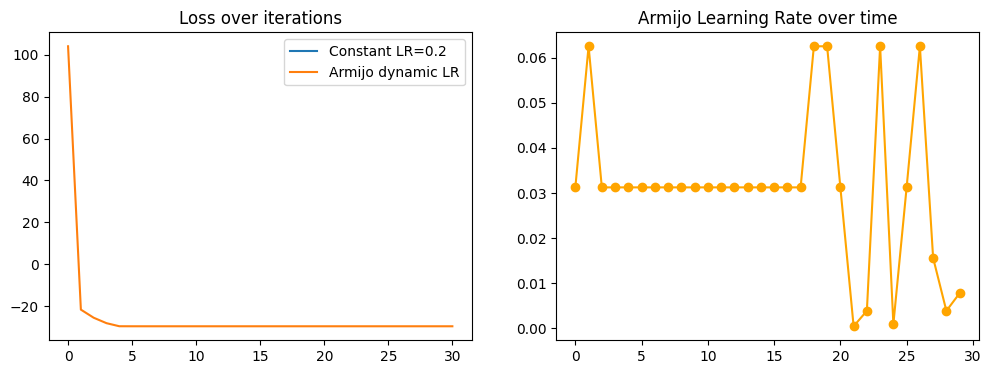

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(f3(hist_const), label="Constant LR=0.2")
ax[0].plot(f3(hist_arm), label="Armijo dynamic LR")
ax[0].set_title("Loss over iterations")
ax[0].legend()
ax[1].plot(lr_arm, color='orange', marker='o')
ax[1].set_title("Armijo Learning Rate over time")
plt.show()

* **Question:** Observe the right plot. When does the Armijo algorithm choose a smaller learning rate?
* **Expected Conclusion:** Line search automates step-size selection, shrinking it in steep regions to guarantee stability, while allowing larger steps in flat regions.


### Module C: 2D Trajectories & Ill-conditioning (10 min)

**Goal:** See how 2D geometry (ill-conditioning, saddles) affects the trajectory.
**Math:** Ill-conditioned convex function $f(x,y) = 0.5(x^2 + 10y^2)$. The gradient points "across" the valley rather than towards the minimum.


In [14]:
def f_2d(X): return 0.5 * (X[0]**2 + 10 * X[1]**2)
def grad_2d(X): return np.array([X[0], 10 * X[1]])

In [15]:
def gd_2d(start_X, lr, iters):
    history = [start_X]
    # TODO: Vectorized 2D GD
    return np.array(history)

In [16]:
# Run and plot
hist_2d = gd_2d([3.0, 1.0], lr=0.15, iters=30)

In [17]:
# Boilerplate plotting
x_grid = np.linspace(-4, 4, 100)
y_grid = np.linspace(-1.5, 1.5, 100)
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)
Z = 0.5 * (X_mesh**2 + 10 * Y_mesh**2)

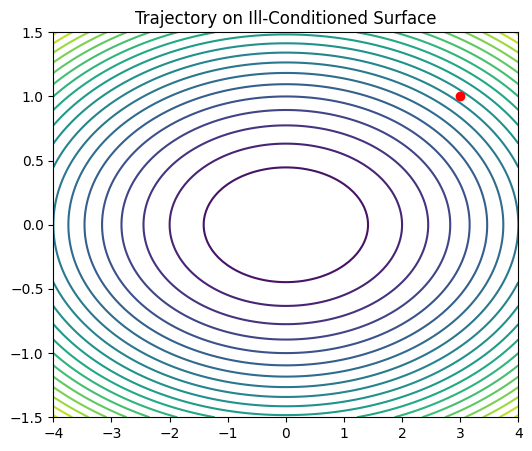

In [18]:
plt.figure(figsize=(6,5))
plt.contour(X_mesh, Y_mesh, Z, levels=20, cmap='viridis')
plt.plot(hist_2d[:, 0], hist_2d[:, 1], 'r-o')
plt.title("Trajectory on Ill-Conditioned Surface")
plt.show()

* **Question:** Why does the red line zigzag horizontally instead of going straight to (0,0)?
* **Expected Conclusion:** Ill-conditioning (one axis curves much faster than the other) causes severe zigzagging. A uniform learning rate struggles with different curvatures.


TASK: Examine fuction g(x,y) = x^2/2 +1/4y^4-1/2y^2

TODO: Create your experiment examine starting from (2.5,0.001),(2.5,-0.001),(2.5,0.0)

### Module D: Stochastic Gradient Descent (SGD) (8–10 min)

**Goal:** Minimize a one-dimensional function efficiently when the objective is an average of many components.

**Math:** Suppose
$f(x) = \frac{1}{n} \sum_{i=1}^{n} f_i(x)$

Instead of computing the full derivative
$f'(x) = \frac{1}{n} \sum_{i=1}^{n} f_i'(x),$

SGD uses a random sample ( i_k ) at each step:

$
x_{k+1} = x_k - \eta , f_{i_k}'(x_k)
$

Equivalently,

$
x_{k+1} = x_k - \eta \left( f'(x_k) + \xi_k \right),
$

where ( $\xi_k$ ) is zero-mean noise.

**Key Idea:**
SGD replaces the exact gradient with a noisy estimate, reducing computational cost per step but introducing variance in the trajectory.

**Effect:**

* Faster iterations
* Noisy convergence
* Requires smaller (or decaying) learning rate for stability


#### Task 1: Implement Noisy SGD (1D)

To simulate stochasticity, assume:

$g_k = f'(x_k) + \xi_k$

where ($ \xi_k \sim \mathcal{N}(0, \sigma^2)$ ).

Update rule:

$
x_{k+1} = x_k - \eta g_k
$


In [19]:
def sgd_1d(start, lr, iterations, grad, sigma=0.1):
    x = start
    history = [x]

    # TODO Generate Implementation

    return np.array(history)

### Experiments

1. Run SGD on:

   * `f1` (convex)
   * `f2` (non-convex)
   * `f3` (multi-well)

2. Try:

   * Small learning rate
   * Large learning rate
   * Small vs large noise


In [20]:
# TODO Generate Your Experiments

#### Task 2:  Implement 2D SGD with Noise

Update rule:

$
X_{k+1} = X_k - \eta (\nabla f(X_k) + \xi_k)
$

where noise is a 2D Gaussian vector.

In [ ]:
def sgd_2d(start, lr, iterations, grad, sigma=0.1):
    X = np.array(start, dtype=float)
    history = [X.copy()]

    # TODO Generate Implementation

    return np.array(history)

### Visualization Task

1. Plot contour lines of `f_2d`
2. Plot optimization trajectory
3. Start from `differnt points` and `different learning rates`
4. Try different noise levels
5. Compare with other methods

In [21]:
# TODO Generate Your Experiments


### Module E: SGD with Momentum (8–10 min)

**Goal:** Accelerate convergence of SGD and reduce oscillations by accumulating past gradients.

**Math:** Let
$
f(x) = \frac{1}{n} \sum_{i=1}^{n} f_i(x)
$
and define the stochastic gradient as before:
$
g_k = f'_{i_k}(x_k) \approx f'(x_k) + \xi_k
$

Momentum introduces a velocity term (v_k) to smooth updates:

$
v_{k+1} = \mu v_k - \eta g_k
$

$
x_{k+1} = x_k + v_{k+1}
$

where ( $\mu \in [0,1)$ ) is the momentum coefficient.

**Key Idea:**
Momentum accumulates a moving average of past gradients to:

* Amplify consistent descent directions
* Damp oscillations caused by noisy stochastic gradients

**Effect:**

* Faster convergence, especially in narrow or ill-conditioned valleys
* Smoother trajectories than plain SGD
* Can use slightly larger learning rates without instability



#### Task 1: Implement SGD with Momentum


In [22]:
def sgd_momentum_1d(start, lr, iterations, grad, sigma=0.1):
    x = start
    history = [x]

    # TODO Generate Implementation

    return np.array(history)

### Experiments

1. Run SGD on:

   * `f1` (convex)
   * `f2` (non-convex)
   * `f3` (multi-well)

2. Try:

   * Small learning rate
   * Large learning rate
   * Small vs large noise


In [23]:
# TODO Generate Your Experiments

#### Task 2:  Implement 2D SGD with Momentum


In [24]:
def sgd_momentum_2d(start, lr, iterations, grad, sigma=0.1):
    X = np.array(start, dtype=float)
    history = [X.copy()]

    # TODO Generate Implementation

    return np.array(history)

### Visualization Task

1. Plot contour lines of `f_2d`
2. Plot optimization trajectory
3. Start from `differnt points` and `different learning rates`
4. Try different momentum coefficients
5. Try different noise levels
6. Compare with other methods

In [21]:
# TODO Generate Your Experiments

4. **Incorporate Numerical Methods for ODEs**:
   - Implement momentum-based gradient descent inspired by the **Euler method** for ODEs:
     $$
     v_{t+1} = \gamma v_t - \eta \nabla f(x_t), \quad x_{t+1} = x_t + v_{t+1}
     $$
     where $ \gamma $ is the momentum coefficient.
   - Discuss how this approach relates to solving $ \ddot{x} + \gamma \dot{x} + \nabla f(x) = 0 $.

## Module F: SDE View - Langevin Dynamics (SGLD) (10 min)

**Goal:** Introduce temperature/noise explicitly to explore the landscape.
**Math:** $x_{k+1} = x_k - \eta \nabla f(x_k) + \sqrt{2\eta T} \cdot \xi$, where $\xi \sim \mathcal{N}(0, I)$.

```python
def sgld_1d(start_x, lr, iters, temp):
    x = start_x
    history = [x]
    for _ in range(iters):
        g = df3(x) # using the double-well function f3

        # TODO: Add Langevin noise proportional to Temperature
        noise = np.random.randn() * np.sqrt(2 * lr * temp)
        x = x - lr * g + noise

        history.append(x)
    return np.array(history)

# Run standard GD (T=0) vs SGLD (T=5.0) starting from a local minimum trap (x = -2)
# f3 has a local minimum around -2 and a global around +2.
h_gd = sgld_1d(-2.0, lr=0.02, iters=200, temp=0.0)
h_sgld = sgld_1d(-2.0, lr=0.02, iters=200, temp=2.0)

plt.plot(h_gd, label="Standard GD (T=0)")
plt.plot(h_sgld, label="SGLD (T=2.0)", alpha=0.7)
plt.title("Escaping Local Minima with SGLD")
plt.legend()
plt.show()
```
* **Question:** Did SGLD stay in the initial local minimum?
* **Expected Conclusion:** Injecting controlled noise (SDE approach) acts like thermodynamic heat, allowing the trajectory to overcome barriers and explore global state space, but it prevents exact convergence (needs a cooling schedule).


## Module G: Numerical Issues in ML (10 min)

**Goal:** See Exploding Gradients and implement a numerical trick (Log-Sum-Exp).

**1. Exploding Gradients via deep linear matrix multiplication:**
```python
# Forward pass of 50 linear layers without activations
x_val = np.random.randn(10)
W_small = np.random.randn(10, 10) * 0.5 # Var < 1 (Vanishing)
W_large = np.random.randn(10, 10) * 1.5 # Var > 1 (Exploding)

norms_small, norms_large = [],[]
v_s, v_l = x_val, x_val

for _ in range(50):
    v_s = W_small @ v_s
    v_l = W_large @ v_l
    norms_small.append(np.linalg.norm(v_s))
    norms_large.append(np.linalg.norm(v_l))

# TODO: Plot norms_small and norms_large (observe axes limits!)
```

**2. The Log-Sum-Exp Trick for Softmax/Cross-Entropy:**
**Problem:** $\log(\sum e^{x_i})$ overflows for large $x$.
**Math:** $\log(\sum e^{x_i}) = m + \log(\sum e^{x_i - m})$ where $m = \max(x)$.

```python
logits = np.array([1000.0, 1000.0, 1000.0])

# Naiive approach
# print(np.log(np.sum(np.exp(logits)))) # RuntimeWarning: overflow! -> inf

# TODO: Implement stable Log-Sum-Exp
m = np.max(logits)
stable_result = m + np.log(np.sum(np.exp(logits - m)))
print("Stable result:", stable_result)
```
* **Question:** Why does subtracting $m$ prevent overflow without changing the mathematical result?
* **Expected Conclusion:** Machine precision is finite. Deep learning requires mathematical refactoring (like Log-Sum-Exp or weight initialization) to keep gradients and activations within safe floating-point ranges.


# 4) TOP 10 COMMON PITFALLS (Read & Remember)

1. **Learning Rate limits:** Setting $\eta$ too high causes `NaN` (divergence); too low causes freezing.
2. **Missing Random Seeds:** Debugging stochastic methods (SGD) is impossible without `np.random.seed()`.
3. **Loss Confusion:** Mixing up average batch loss with full epoch loss on graphs (causes noisy, misleading plots).
4. **$x_k$ vs $f(x_k)$:** Believing optimization converges because loss $f(x_k)$ is flat, while parameters $x_k$ might still be drifting wildly.
5. **Feature Scales:** Passing unnormalized data to GD causes ill-conditioning (zigzagging).
6. **Unfair Comparisons:** Comparing algorithms using different iteration budgets (e.g., comparing 10 steps of full-batch GD vs 10 steps of batch=1 SGD).
7. **Exploding Non-linearities:** Using `exp()` or polynomials without gradient clipping or proper initialization.
8. **Silent Clipping:** Using gradient clipping but not logging when it happens (hides underlying architecture issues).
9. **Naive Softmax:** Implementing cross-entropy without the log-sum-exp trick, leading to silent `NaN`s in production.
10. **Vanishing Momentum:** Initializing momentum $\mu=0.99$ too early before gradients stabilize, shooting the trajectory out of bounds.


 5) SUMMARY & CHECKLIST (10 min)

### Key Takeaways
1. **GD is a dynamical system:** It's the forward Euler discretization of Gradient Flow.
2. **Curvature matters:** The Lipschitz constant (steepness) limits the max learning rate; ill-conditioning slows down convergence.
3. **Line Search automates $\eta$:** Algorithms like Armijo adapt to local geometry, saving manual tuning.
4. **Mini-batches introduce noise:** This noise is actually beneficial—it acts as implicit regularization and helps escape local minima.
5. **Momentum accumulates history:** It dampens zigzagging in ravines and accelerates straight paths (like a heavy ball).
6. **SDEs explain exploration:** Adding explicit noise (Langevin dynamics) formally turns optimization into a physical sampling process.
7. **Numerical stability is mandatory:** Math on paper $\neq$ math in float32. Tricks like Log-Sum-Exp are essential foundations of ML.

### "How I diagnose optimization problems" - Checklist
- [ ] Are inputs normalized? (Fixes ill-conditioning).
-[ ] Is the learning rate reasonable? (Try logarithmic grid search: 1e-1, 1e-2, 1e-3).
- [ ] Did I plot both loss AND parameter norm over time?
- [ ] If loss is spiky, is my batch size too small?
- [ ] If loss diverges to `NaN`, did I try gradient clipping?
- [ ] Are my initial weights too large? (Check variance/exploding gradients).
- [ ] Am I using numerically stable functions for probabilities (Log-Sum-Exp)?
- [ ] Is Momentum shooting me out of the valley? (Try lowering $\mu$).
- [ ] Am I stuck in a local minimum? (Try increasing $\eta$ or adding noise/SGLD).
- [ ] Did I set a random seed for reproducible debugging?